<a href="https://colab.research.google.com/github/Anusree-ss780/ML-LAB/blob/main/experiment%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score


In [8]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
data = pd.read_ csv(url)

In [26]:
data = data[['mpg','displacement']]
data.dropna(inplace = True)

In [11]:
print(data.head())

    mpg  displacement
0  18.0         307.0
1  15.0         350.0
2  18.0         318.0
3  16.0         304.0
4  17.0         302.0


In [27]:
X = data[['displacement']]
y = data['mpg']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

linear_model = LinearRegression()
linear_model.fit(x_train, y_train)
y_pred_linear = linear_model.predict(x_test)

In [15]:
print("Linear Regression:")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_linear))
print("R-squared:", r2_score(y_test, y_pred_linear))

Linear Regression:
Mean Squared Error: 18.102543998358946
R-squared: 0.6633114869465596


In [22]:
degree = [2,3,4]
for degree in degree:
  poly = PolynomialFeatures(degree)
  x_train_poly = poly.fit_transform(x_train)
  x_test_poly = poly.transform(x_test)
  model = LinearRegression()
  model.fit(x_train_poly,y_train)
  y_pred_poly = model.predict(x_test_poly)
  print("\nDegree=",degree)
  print("MSE=",mean_squared_error(y_test,y_pred_poly))
  print("R2=",r2_score(y_test,y_pred_poly))


Degree= 2
MSE= 15.10735356108076
R2= 0.7190189176110284

Degree= 3
MSE= 14.943631793037289
R2= 0.722063972418907

Degree= 4
MSE= 14.961486893912738
R2= 0.7217318860908903


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


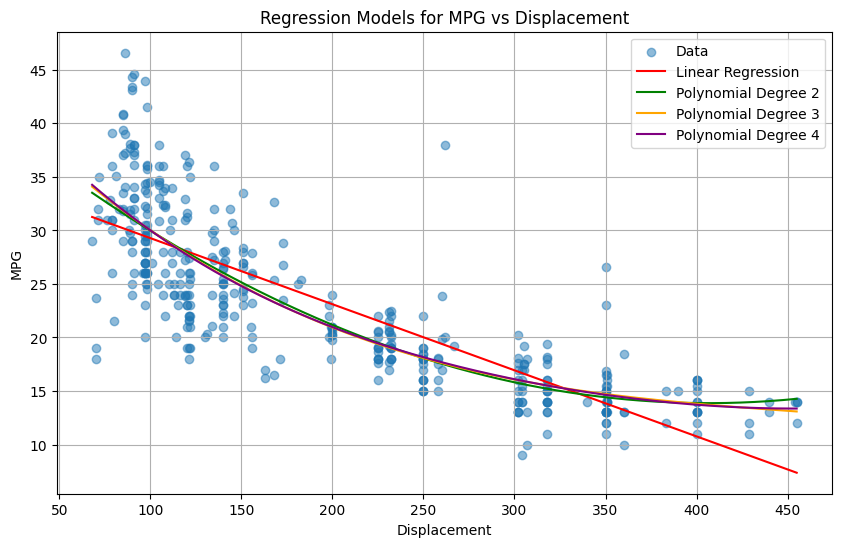

In [31]:
x_range = np.linspace(X['displacement'].min(), X['displacement'].max(), 300).reshape(-1, 1)
plt.figure(figsize=(10,6))
plt.scatter(X['displacement'], y, alpha=0.5, label='Data')
plt.plot(x_range, linear_model.predict(x_range), color='red', label='Linear Regression')
colors=['green','orange','purple']

# Ensure `X` is used for fitting PolynomialFeatures for plotting full range
# We fit the polynomial model on the entire dataset X for plotting purposes to show the curve over the full range.
for degree, color in zip([2,3,4], colors):
  poly = PolynomialFeatures(degree)
  X_poly_full = poly.fit_transform(X) # Fit on the full dataset X
  model_full = LinearRegression()
  model_full.fit(X_poly_full, y)

  # Predict on the x_range after transforming it with the same PolynomialFeatures
  plt.plot(x_range, model_full.predict(poly.transform(x_range)), color=color, label=f'Polynomial Degree {degree}')

plt.xlabel("Displacement")
plt.ylabel("MPG")
plt.title("Regression Models for MPG vs Displacement")
plt.legend()
plt.grid()
plt.show()